# Electric vehicle battery capacities

Useable battery capacity of current European EV models, taken from
**[EV Database](https://ev-database.org/)** (v5.2.0, filter view captured 2026-07-19,
103 listed vehicles over 30 manufacturers).

Trim variants sharing the same pack are commented out in the record list, leaving
**67 distinct model/pack entries from 11 manufacturers**.

Outputs: a capacity histogram, a per-manufacturer model listing, and a summary table.

> Values are the *useable* battery capacity from each vehicle card (kWh), not gross.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


## Dataset

Each record is `(manufacturer, model, useable_battery_kWh)`. Commented-out lines are
sibling trims with an identical pack size, excluded so one pack is not counted twice.

In [2]:
records = [
    ('BMW', 'i3 50 xDrive', 108.7),
    ('BMW', 'iX3 50 xDrive (MY26)', 108.7),
    ('BMW', 'iX3 40 (MY26)', 82.6),
    ('Hyundai', 'IONIQ 9 Long Range AWD', 106.0),
    # ('Hyundai', 'IONIQ 9 Long Range RWD', 106.0),
    # ('Hyundai', 'IONIQ 9 Performance AWD', 106.0),
    ('Polestar', '3 Dual Motor (MY26)', 102.0),
    # ('Polestar', '3 Performance (MY26)', 102.0),
    ('Polestar', '3 Rear Motor (MY26)', 88.0),
    # ('Volvo', 'EX90 Twin Motor Performance (MY26-27)', 102.0),
    ('Volvo', 'EX90 Twin Motor (MY26-27)', 102.0),
    ('Volvo', 'EX60 P10 AWD (MY27)', 91.0),
    ('Volvo', 'EX90 Single Motor (MY26-27)', 88.0),
    ('Volvo', 'EX60 P6 (MY27)', 80.0),
    ('Kia', 'EV9 99.8 kWh AWD', 96.0),
    # ('Kia', 'EV9 99.8 kWh RWD', 96.0),
    # ('Kia', 'EV9 99.8 kWh AWD GT-Line', 96.0),
    # ('Kia', 'EV9 99.8 kWh AWD GT', 96.0),
    ('Kia', 'EV4 Hatchback 81.4 kWh (MY25-26)', 78.0),
    ('Kia', 'EV5 81.4 kWh (MY26)', 78.0),
    # ('Kia', 'EV4 Hatchback 81.4 kWh (MY27)', 78.0),
    # ('Kia', 'EV4 Fastback 81.4 kWh (MY25-26)', 78.0),
    # ('Kia', 'EV4 Hatchback 81.4 kWh GT (MY27)', 78.0),
    # ('Kia', 'EV4 Hatchback 81.4 kWh AWD (MY27)', 78.0),
    ('Kia', 'EV3 GT (MY27)', 78.0),
    # ('Kia', 'EV5 81.4 kWh GT (MY26)', 78.0),
    ('Kia', 'EV5 81.4 kWh AWD (MY26)', 78.0),
    ('Kia', 'EV9 76.1 kWh RWD', 73.0),
    # ('Kia', 'PV5 Passenger 71.2 kWh (MY27)', 67.0),
    ('Kia', 'PV5 Passenger 71.2 kWh - 7 Seats (MY27)', 67.0),
    ('Kia', 'EV2 61 kWh (MY27)', 58.0),
    ('Kia', 'EV4 Hatchback 58.3 kWh (MY27)', 55.0),
	# ('Kia', 'EV4 Hatchback 58.3 kWh (MY25-26)', 55.0),
	# ('Kia', 'EV4 Fastback 58.3 kWh (MY25-26)', 55.0),
    ('Mercedes-Benz', 'GLC 400 4MATIC', 94.0),
    ('Mercedes-Benz', 'C 400 4MATIC', 94.0),
    ('Mercedes-Benz', 'CLA 250+', 85.0),
    ('Mercedes-Benz', 'GLB 250+', 85.0),
    ('Mercedes-Benz', 'CLA Shooting Brake 250+', 85.0),
    ('Mercedes-Benz', 'CLA 350 4MATIC', 85.0),
    ('Mercedes-Benz', 'GLB 350 4MATIC', 85.0),
    ('Mercedes-Benz', 'GLC 250', 85.0),
    ('Mercedes-Benz', 'GLC 300 4MATIC', 85.0),
    ('Mercedes-Benz', 'CLA Shooting Brake 350 4MATIC', 85.0),
    ('Mercedes-Benz', 'CLA 250', 71.0),
    ('Mercedes-Benz', 'CLA 200', 58.0),
    ('Mercedes-Benz', 'CLA Shooting Brake 200', 58.0),
    ('Škoda', 'Peaq 90 (MY27)', 86.0),
    # ('Škoda', 'Peaq 90x (MY27)', 86.0),
    ('Škoda', 'Enyaq 85 (MY27)', 77.0),
    ('Škoda', 'Enyaq Coupe 85 (MY27)', 77.0),
    # ('Škoda', 'Enyaq 85x (MY27)', 77.0),
    ('Škoda', 'Enyaq RS (MY27)', 77.0),
    # ('Škoda', 'Enyaq Coupe RS (MY27)', 77.0),
    # ('Škoda', 'Enyaq Coupe 85x (MY27)', 77.0),
    ('Škoda', 'Peaq 60 (MY27)', 59.0),
    ('Škoda', 'Epiq 55 (MY27)', 51.7),
    # ('Volkswagen', 'ID.7 Tourer 86 kWh (MY27)', 86.0),
    ('Volkswagen', 'ID.7 86 kWh (MY27)', 86.0),
    # ('Volkswagen', 'ID. Buzz LWB GTX', 86.0),
    ('Volkswagen', 'ID. Buzz LWB Pro', 86.0),
    # ('Volkswagen', 'ID.7 Tourer GTX (MY27)', 86.0),
    ('Volkswagen', 'ID.7 GTX (MY27)', 86.0),
    # ('Volkswagen', 'ID. Buzz LWB Pro (MY27)', 86.0),
    # ('Volkswagen', 'ID. Buzz LWB Pro 4MOTION (MY27)', 86.0),
    ('Volkswagen', 'ID. Buzz LWB GTX (MY27)', 86.0),
    ('Volkswagen', 'ID.3 Neo 79 kWh (MY27)', 79.0),
    ('Volkswagen', 'ID.4 Pro (MY27)', 79.0),
    ('Volkswagen', 'ID. Buzz NWB Pro', 79.0),
    ('Volkswagen', 'ID.5 Pro (MY27)', 79.0),
    # ('Volkswagen', 'ID. Buzz NWB Pro (MY27)', 79.0),
    # ('Volkswagen', 'ID. Buzz NWB GTX', 79.0),
    # ('Volkswagen', 'ID. Buzz NWB Pro 4MOTION (MY27)', 79.0),
    ('Volkswagen', 'ID. Buzz NWB GTX (MY27)', 79.0),
    # ('Volkswagen', 'ID.7 Tourer 77 kWh (MY27)', 77.0),
    ('Volkswagen', 'ID.7 77 kWh (MY27)', 77.0),
    ('Volkswagen', 'ID.4 Pro 4MOTION (MY27)', 77.0),
    # ('Volkswagen', 'ID.4 GTX (MY27)', 77.0),
    ('Volkswagen', 'ID.5 GTX (MY27)', 77.0),
    ('Volkswagen', 'ID.5 Pro 4MOTION (MY27)', 77.0),
    # ('Volkswagen', 'ID.7 Tourer 59 kWh (MY27)', 59.0),
    ('Volkswagen', 'ID.7 59 kWh (MY27)', 59.0),
    ('Volkswagen', 'ID.3 Neo 58 kWh (MY27)', 58.0),
    ('Volkswagen', 'ID.4 Pure (MY27)', 58.0),
    ('Volkswagen', 'ID.5 Pure (MY27)', 58.0),
    ('Volkswagen', 'ID. Polo 155 kW - 52 kWh (MY27)', 51.7),
    # ('Volkswagen', 'ID. Cross 155 kW - 52 kWh (MY27)', 51.7),
    ('Volkswagen', 'ID.3 Neo 50 kWh (MY27)', 50.0),
    ('Renault', 'Scenic E-Tech EV87 220hp (TU2025)', 87.0),
    ('Renault', 'Megane E-Tech EV60 220hp (TU2025)', 60.0),
    ('Renault', 'Scenic E-Tech EV60 170hp (TU2025)', 60.0),
    ('Renault', '5 E-Tech 52kWh 150hp', 52.0),
    ('Renault', '4 E-Tech 52kWh 150hp', 52.0),
    ('Audi', 'Q4 e-tron performance (MY27)', 77.0),
    ('Audi', 'Q4 Sportback e-tron performance (MY27)', 77.0),
    #('Audi', 'Q4 e-tron quattro performance (MY27)', 77.0),
    # ('Audi', 'Q4 Sportback e-tron quattro performance (MY27)', 77.0),
    # ('Audi', 'Q4 e-tron quattro (MY27)', 77.0),
    # ('Audi', 'Q4 Sportback e-tron quattro (MY27)', 77.0),
    ('Audi', 'Q4 e-tron (MY27)', 59.0),
    ('Audi', 'Q4 Sportback e-tron (MY27)', 59.0),
    ('CUPRA', 'Tavascan 210 kW - 77 kWh Endurance (MY27)', 77.0),
    # ('CUPRA', 'Tavascan 250 kW - 77 kWh VZ (MY27)', 77.0),
]

df = pd.DataFrame(records, columns=["manufacturer", "model", "battery_kWh"])
print(f"{len(df)} vehicles, {df['manufacturer'].nunique()} manufacturers")
df.head(10)


67 vehicles, 11 manufacturers


,manufacturer,model,battery_kWh
0,BMW,i3 50 xDrive,108.7
1,BMW,iX3 50 xDrive (MY26),108.7
2,BMW,iX3 40 (MY26),82.6
3,Hyundai,IONIQ 9 Long Range AWD,106.0
4,Polestar,3 Dual Motor (MY26),102.0
5,Polestar,3 Rear Motor (MY26),88.0
6,Volvo,EX90 Twin Motor (MY26-27),102.0
7,Volvo,EX60 P10 AWD (MY27),91.0
8,Volvo,EX90 Single Motor (MY26-27),88.0
9,Volvo,EX60 P6 (MY27),80.0


## 1. Battery size histogram

Distribution of useable capacity over the 67 models: 2 kWh bins across 48-110 kWh,
median marked. Median is 78.0 kWh, the range 50.0-108.7 kWh. Saved as `battery_histogram.pdf`.

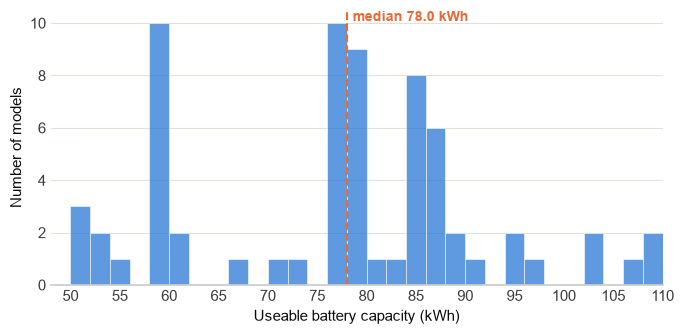

In [3]:
import numpy as np
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(7, 3.5))

BLUE = "#2a78d6"
BIN_W = 2          # narrow 2 kWh bins
lo, hi = 48, 110
sns.histplot(
    data=df, x="battery_kWh",
    bins=np.arange(lo, hi + BIN_W, BIN_W),
    color=BLUE, edgecolor="white", linewidth=0.4,
    ax=ax,
)

# ax.set_title("Useable battery capacity of European EVs", fontsize=14, color="#0b0b0b", pad=12, loc="left")
ax.set_xlabel("Useable battery capacity (kWh)", fontsize=11, color="#0b0b0b")
ax.set_ylabel("Number of models", fontsize=11, color="#0b0b0b")

# x-axis refinement to match the narrow bins:
#   major tick + label every 5 kWh, minor tick on every 1 kWh bin edge
ax.set_xlim(lo, hi)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="x", which="minor", length=3, colors="#3B3B3B")

# recessive chrome
ax.grid(axis="x", visible=False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="both", which="major", colors="#3B3B3B", length=0)

# median reference line
med = df["battery_kWh"].median()
ax.axvline(med, color="#eb6834", linestyle="--", linewidth=1.5)
ax.text(med + 0.6, ax.get_ylim()[1] * 0.96, f"median {med:.1f} kWh",
        color="#eb6834", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("battery_histogram.pdf", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
df["battery_kWh"].describe().round(1)


count     67.0
mean      76.8
std       14.8
min       50.0
25%       60.0
50%       78.0
75%       85.5
max      108.7
Name: battery_kWh, dtype: float64

## 2. Manufacturers and their model types

Every manufacturer with its model variants and pack sizes, ordered by model count.

In [5]:
from collections import defaultdict

by_mfr = defaultdict(list)
for mfr, model, batt in records:
    by_mfr[mfr].append((model, batt))

# sort manufacturers by number of models (desc), then name
for mfr in sorted(by_mfr, key=lambda m: (-len(by_mfr[m]), m)):
    models = by_mfr[mfr]
    print(f"\n{mfr}  ({len(models)} models)")
    print("-" * (len(mfr) + 14))
    for model, batt in models:
        print(f"  - {model:<42} {batt:>6.1f} kWh")



Volkswagen  (19 models)
------------------------
  - ID.7 86 kWh (MY27)                           86.0 kWh
  - ID. Buzz LWB Pro                             86.0 kWh
  - ID.7 GTX (MY27)                              86.0 kWh
  - ID. Buzz LWB GTX (MY27)                      86.0 kWh
  - ID.3 Neo 79 kWh (MY27)                       79.0 kWh
  - ID.4 Pro (MY27)                              79.0 kWh
  - ID. Buzz NWB Pro                             79.0 kWh
  - ID.5 Pro (MY27)                              79.0 kWh
  - ID. Buzz NWB GTX (MY27)                      79.0 kWh
  - ID.7 77 kWh (MY27)                           77.0 kWh
  - ID.4 Pro 4MOTION (MY27)                      77.0 kWh
  - ID.5 GTX (MY27)                              77.0 kWh
  - ID.5 Pro 4MOTION (MY27)                      77.0 kWh
  - ID.7 59 kWh (MY27)                           59.0 kWh
  - ID.3 Neo 58 kWh (MY27)                       58.0 kWh
  - ID.4 Pure (MY27)                             58.0 kWh
  - ID.5 Pure (MY27)  

### Summary table: models per manufacturer

Model count plus min / max / mean pack size per manufacturer.

In [6]:
summary = (df.groupby("manufacturer")
             .agg(models=("model", "count"),
                  min_kWh=("battery_kWh", "min"),
                  max_kWh=("battery_kWh", "max"),
                  mean_kWh=("battery_kWh", "mean"))
             .sort_values("models", ascending=False)
             .round(1))
summary


,models,min_kWh,max_kWh,mean_kWh
manufacturer,,,,
Volkswagen,19,50.0,86.0,72.7
Mercedes-Benz,13,58.0,94.0,81.2
Kia,9,55.0,96.0,73.4
Škoda,6,51.7,86.0,71.3
Renault,5,52.0,87.0,62.2
Audi,4,59.0,77.0,68.0
Volvo,4,80.0,102.0,90.2
BMW,3,82.6,108.7,100.0
Polestar,2,88.0,102.0,95.0
